In [10]:
#Program to perform Exploratory Data Analysis on Titanic Dataset

In [ ]:

# head(): Displays the first few rows of the dataset.
# info(): Provides dataset structure, data types, and non-null counts.
# isnull().sum(): Checks missing values in each column.
# describe(): Generates statistical summary of numerical columns.
# drop(): Removes unnecessary columns from the dataset.
# fillna(): Fills missing values (used for imputing Age).
# groupby(): Groups data based on categorical features for analysis.
# transform(): Applies group-wise calculations and fills missing values.
# corr(): Computes correlation between numerical features.
# catplot() / violinplot() / heatmap(): Visualizes relationships and survival patterns.


In [2]:
import pandas as pd
titanic_df=pd.read_csv("train.csv")
titanic_df.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic_cleaned= titanic_df.drop(['PassengerId','Name','Ticket','Fare','Cabin'],axis=1)
titanic_cleaned.head() 

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [9]:
titanic_cleaned.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 48.9+ KB


In [11]:
titanic_cleaned["Age"]=titanic_cleaned["Age"].fillna(titanic_cleaned.groupby("Pclass")["Age"].transform("mean"))

In [12]:
titanic_cleaned.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Embarked    2
dtype: int64

In [14]:
!pip install seaborn 


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

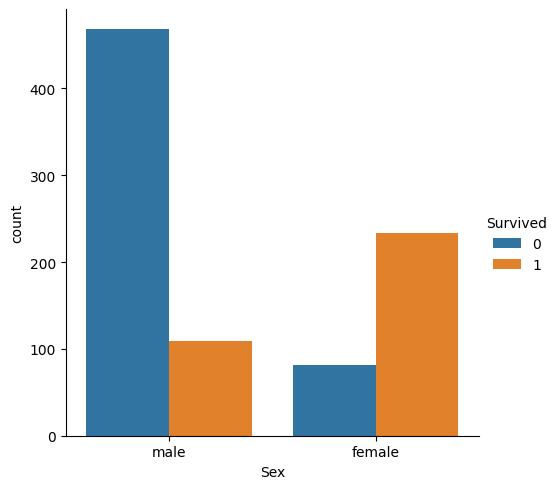

In [19]:
sns.catplot(x="Sex", hue="Survived", kind="count", data=titanic_cleaned)

In [20]:
titanic_cleaned.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [21]:
group1=titanic_cleaned.groupby(['Sex','Survived'])

In [22]:
gender_survived=group1.size().unstack()

<Axes: xlabel='Survived', ylabel='Sex'>

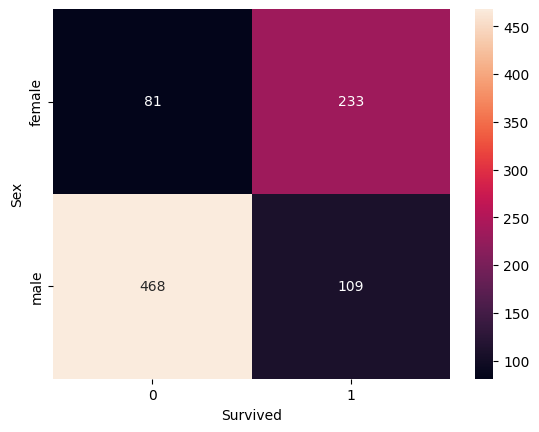

In [24]:
sns.heatmap(gender_survived,annot=True,fmt="d")

<Axes: xlabel='Survived', ylabel='Pclass'>

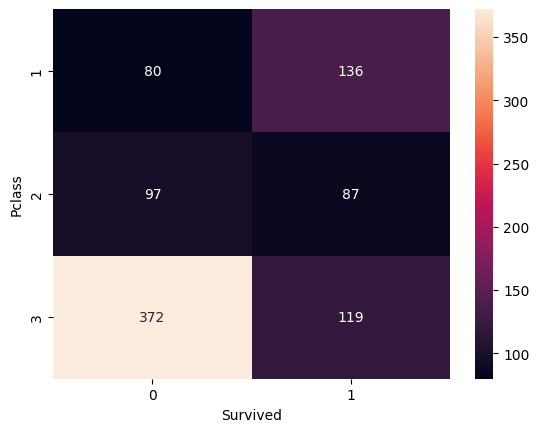

In [25]:
group2=titanic_cleaned.groupby(['Pclass', 'Survived'])
pclass=group2.size().unstack()
sns.heatmap(pclass, annot=True, fmt="d") 

<Axes: xlabel='Sex', ylabel='Age'>

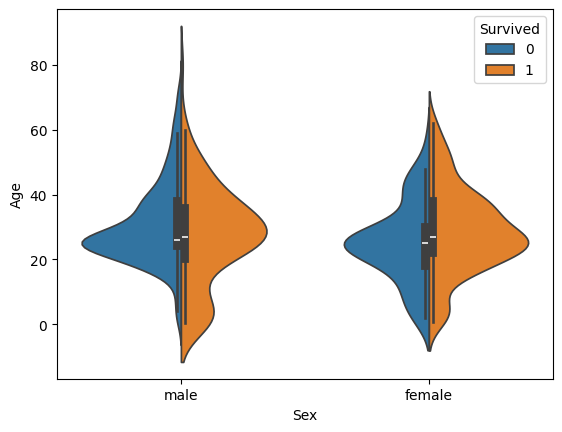

In [26]:
sns.violinplot(x="Sex", y="Age", hue="Survived", data=titanic_cleaned, split=True)

In [27]:
titanic_corr=titanic_cleaned.drop(['Sex', 'Embarked'], axis=1)
titanic_corr.corr(method="pearson") 

,Survived,Pclass,Age,SibSp,Parch
Survived,1.000000,-0.338481,-0.050504,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.403858,0.083081,0.018443
Age,-0.050504,-0.403858,1.000000,-0.243452,-0.175799
SibSp,-0.035322,0.083081,-0.243452,1.000000,0.414838
Parch,0.081629,0.018443,-0.175799,0.414838,1.000000


<Axes: >

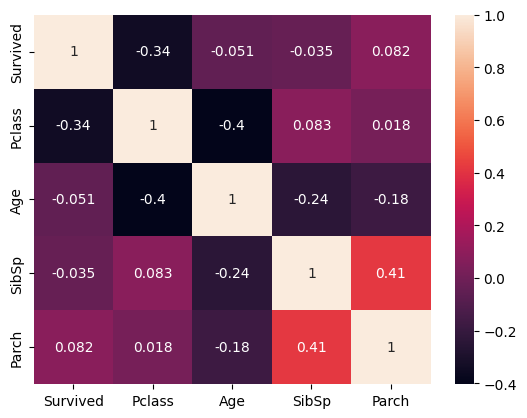

In [28]:
sns.heatmap(titanic_corr.corr(method="pearson"), annot=True, vmax=1)

In [29]:
titanic_corr.corr(method='pearson')

,Survived,Pclass,Age,SibSp,Parch
Survived,1.000000,-0.338481,-0.050504,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.403858,0.083081,0.018443
Age,-0.050504,-0.403858,1.000000,-0.243452,-0.175799
SibSp,-0.035322,0.083081,-0.243452,1.000000,0.414838
Parch,0.081629,0.018443,-0.175799,0.414838,1.000000
